In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('data/Telco_Customer_Churn.csv')


In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

# Data Validity and Cleaning

The data being reviewed is the Telecom Data. It has 7043 rows and 21 columns with a target feature called "Churn".

### Cleaning

In [5]:
df.dtypes   

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
#Testing if the data has any missing values
df.isnull().values.any()

#My data has no missing values

np.False_

There "TotalCharges" Column is displayed as a string. It should be converted to a numeric float type.

In [7]:
#Apply pd.to_numeric to the 'TotalCharges' column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].dtypes)

float64


In [8]:
#I was curious as to why the 'TotalCharges' column was being read
# as an object instead of a float. I decided to investigate further 
# and found that there were some null values after conversion 
# This shows some rows may have been empty.


print("Nulls after conversion:", df['TotalCharges'].isna().sum())

Nulls after conversion: 11


These 11 missing values belong to brand-new customers with a tenure of 0 months who haven't received their first bill yet. These rows can be dropped.

In [9]:
#Dropping rows with null values in the 'TotalCharges' column
df.dropna(subset=['TotalCharges'], inplace=True)

#Checking the shape of the DataFrame after dropping rows with null values
print("Shape after dropping nulls:", df.shape)


Shape after dropping nulls: (7032, 21)


#### Checking for Duplicates

In [10]:
#Checking for duplicate values
df.duplicated().any()

#My data has no duplicate values

np.False_

In [11]:
#Checking if the each row in the customerID column has a 
# unique string


print("Is customerID unique?", df['customerID'].is_unique)

Is customerID unique? True


In [12]:
#Since each row in the customerID column has a unique string,
# This column can be dropped as it will not be useful for analysis. 
# It is an identifier column.


#Dropping the 'customerID' column
df = df.drop(columns=['customerID'], errors='ignore')

df.shape



(7032, 20)

The row "customerID" was dropped as it holds no predictive power. The number of columns therefore reduced from 21 to 20. 

### Verifying Outliers

Looking for any outliers in the only numerical columns which are 'tenure', 'MonthlyCharges', and 'TotalCharges'

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

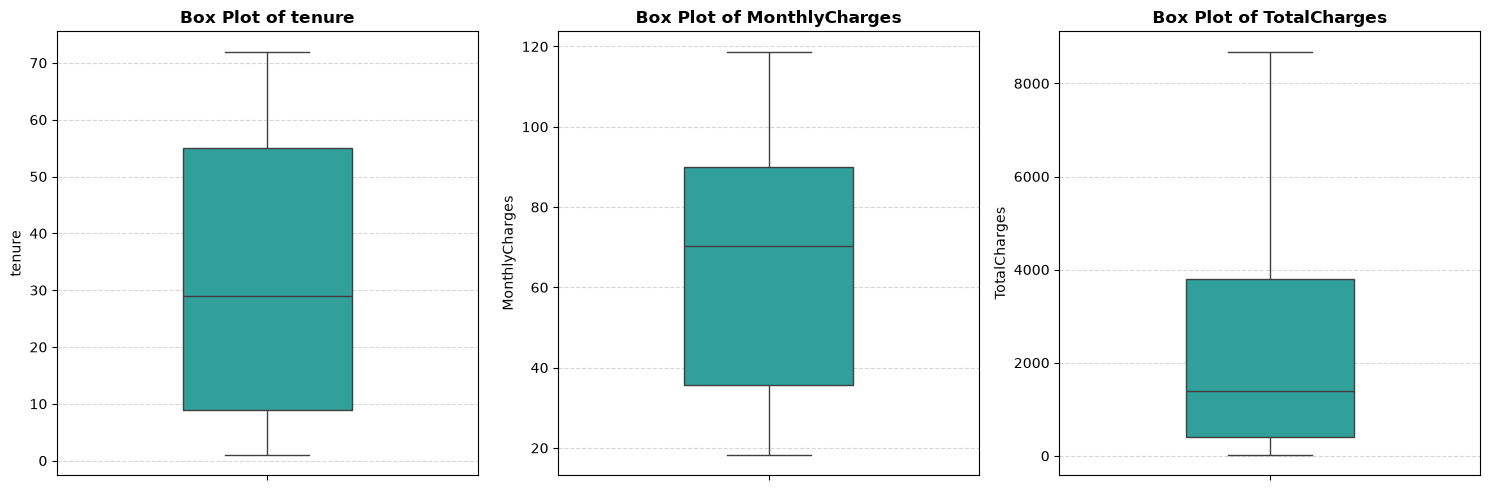

In [14]:
#The numerical columns in the dataset are 'tenure', 'MonthlyCharges', and 'TotalCharges'.
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

#Setting up the matplotlib plotting area that is 15 units wide and 5 units tall.
#This is spacious enough to accommodate for three box plots side by side.
plt.figure(figsize=(15, 5))

# Looping through each feature to generate its individual box plot
for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    
    # Creating the box plot using seaborn
    sns.boxplot(y=df[col], color='lightseagreen', width=0.4)
    
    # Adding titles and labels for clarity
    plt.title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adjusting layout so labels don't overlap
plt.tight_layout()
plt.show()

The dataset is clean and bounded without any extreme outliers that need to be removed:

Tenure is distributed evenly across the customer base from 1 month to 72 months, with a median around 29 months. There are no values beyond the boundaries.

MonthlyCharges spans evenly from roughly $18 to $118 without any disconnected points outside the whiskers.

TotalCharges shows a right-skewed distribution (concentrated heavily on lower costs due to shorter-tenure clients, with a long upper tail for high-tenure clients). But even with this tail, no points cross the statistical outlier threshold lines.


In [15]:
# Saving the cleaned DataFrame to my data folder
df.to_csv("data/Telco_cleaned.csv", index=False)

In [16]:
print(df.shape)

(7032, 20)
